In [33]:
# 패키지 확인
import sklearn
import matplotlib.pyplot as plt
import platform
import pandas as pd
sklearn.__version__

'1.8.0'

In [34]:
if platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")  # Windows 내장
elif platform.system() == "Darwin":
    plt.rc("font", family="AppleGothic")  # macOS
else:
    plt.rc("font", family="NanumGothic")  # Ubuntu: sudo apt install fonts-nanum

plt.rc("axes", unicode_minus=False)

도미 빙어 데이터 입력

In [35]:
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7,
                31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5,
                34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0,
                38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0,
                500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0,
                610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0,
                714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2,
                12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2,
                13.4, 12.2, 19.7, 19.9]

In [36]:
# fish_data, fish_target 구성
length = bream_length + smelt_length
weight = bream_weight + smelt_weight

fish_data = [[l,w] for l,w in zip(length, weight)]
fish_target = [1]*35 + [0]*14 

print(f'전체 : {len(fish_data)}마리')

전체 : 49마리


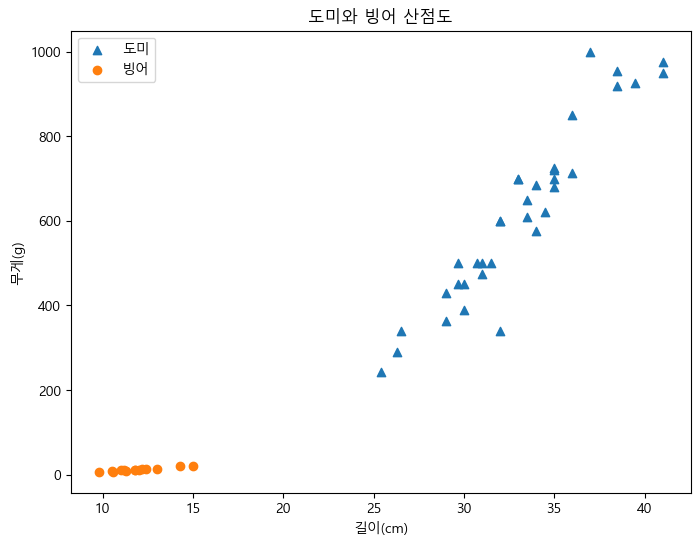

In [37]:
# 산점도 시각화
plt.figure(figsize=(8,6))
plt.scatter(bream_length, bream_weight, marker='^', label="도미")
plt.scatter(smelt_length, smelt_weight, marker="o", label="빙어")
plt.xlabel("길이(cm)")
plt.ylabel("무게(g)")
plt.title("도미와 빙어 산점도")
plt.legend()
plt.show()

In [38]:
# KNeighborsClassifier 학습
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

kn.fit(fish_data, fish_target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# 예측 + 정확도 -> "왜 1.0인가?" 토론 
predict = kn.predict([[30,600]])
print("예측 : ", predict)
print("정확도 : ", kn.score(fish_data, fish_target))

예측 :  [1]
정확도 :  1.0


---
## train_test_split

In [40]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    fish_data, fish_target, random_state=42)

In [41]:
from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()

kn.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [42]:
train_score = kn.score(train_input, train_target)
test_score = kn.score(test_input, test_target)

In [43]:
print(f'train 정확도 : {train_score:.4f}')
print(f"test 정확도 : {test_score:.4f}")

train 정확도 : 1.0000
test 정확도 : 1.0000


In [44]:
print(f"train — 도미: {train_target.count(1)}, 빙어: {train_target.count(0)}")
print(f"test — 도미: {test_target.count(1)}, 빙어: {test_target.count(0)}")

train — 도미: 25, 빙어: 11
test — 도미: 10, 빙어: 3


---
## titanic

### 실습 3 — 타이타닉 문제 정의 워크숍

1. 이 데이터로 무엇을 예측할 수 있는가?
- 성별, 연령, 객실등급 간 생존율 등

2. 이것은 어떤 ML 유형인가? (지도/비지도? 분류/회귀?)
- 지도, 분류

3. 생존에 영향을 줄 특성(컬럼) 가설 3가지와 근거를 작성하라.
- Pclass : 객실등급 차이가 객실의 위치를 결정할 수 있기 때문
- Sex / Age : 어린아이와 여성을 먼저 구조하여 구명보트에 태우는 관행 등 당시의 사회 인식 구조를 파악할 수 있기 때문

4. 직접 쓰기 어려운 컬럼은? 이유는?
- Name, Ticket : 생존율과 직접적인 영향이 없기 때문 -> 고유값이라 분류하는 의미가 없음
- Cabin : 결측치가 너무 많아 사용이 어려움
- **SibSp, Parch, Fare, Embarked**
```text
    Fare : 요금이 높을수록 상위 객실 → 생존율과 연관 가능
    SibSp / Parch : 가족이 많으면 이동이 느려짐 → 생존율에 영향 가능
    Embarked : 탑승 항구별로 객실 배정이 달랐을 수 있음
    Cabin : 객실 번호로 위치(갑판층) 유추 가능, 다만 결측치가 너무 많아 사용이 어려움

In [46]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

In [49]:
print("크기:", df.shape)
print("\n첫 3행:")
print(df.head(3))
print("\n생존 분포:")
print(df["Survived"].value_counts())
print("\n결측값:")
print(df.isnull().sum()[df.isnull().sum() > 0])

크기: (891, 12)

첫 3행:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

생존 분포:
Survived
0    549
1    342
Name: count, dtype: int64

결측값:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
